# Setup de Librerias

In [14]:
# For calculation
import numpy as np

# For visualization
import matplotlib.pyplot as plt
from skimage import io, color, filters, measure
import seaborn as sns

# Funciones a Utilizar

Limpieza de ruido: conservar el blob de mayor área

In [15]:
def keep_largest_blob(binary):
    """Remove noise from a binary image, keeping only the largest connected blob.

    Labels every connected component in the binary image, measures each
    component's area, and returns a binary mask containing only the
    component with the largest area.

    Parameters
    ----------
    binary : ndarray (bool)
        The segmented (binarized) image, e.g. the output of `segment_otsu`.

    Returns
    -------
    cleaned : ndarray (bool)
        Binary mask with only the largest-area blob retained.
    """
    labels = measure.label(binary)

    if labels.max() == 0:
        return binary

    areas = np.bincount(labels.ravel())
    areas[0] = 0  # ignore the background label
    largest_label = np.argmax(areas)

    return labels == largest_label

Segmentación de Otsu

In [25]:
def segment_otsu(image_path, invert=False):
    """Read an image and segment it using Otsu's thresholding method.

    After thresholding, only the largest connected blob is kept to
    remove noise (see `keep_largest_blob`).

    Parameters
    ----------
    image_path : str
        Path to the image file.
    invert : bool
        If True, foreground is treated as pixels BELOW the threshold
        (useful when letters are dark on a light background).

    Returns
    -------
    gray : ndarray
        The original image in grayscale.
    binary : ndarray (bool)
        The segmented (binarized) image, with only the largest blob retained.
    threshold : float
        The threshold value chosen automatically by Otsu's method.
    """
    img = io.imread(image_path)
    gray = color.rgb2gray(img) if img.ndim == 3 else img

    threshold = filters.threshold_otsu(gray)
    binary = gray < threshold if invert else gray > threshold
    binary = keep_largest_blob(binary)

    return gray, binary, threshold

Mostrar Segmentacion

In [21]:
def show_segmentation(image_path, invert=False):
    """Segment an image with Otsu's method and display original vs. result."""
    gray, binary, threshold = segment_otsu(image_path, invert=invert)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(binary, cmap="gray")
    axes[1].set_title(f"Otsu segmentation (t={threshold:.3f})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    return binary

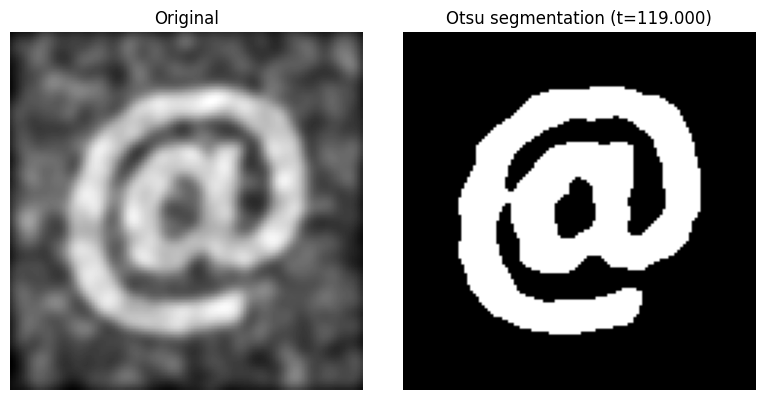

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [38]:
show_segmentation("training/char_05_002.png", invert=False)

Rellenar Agujeros

In [27]:
def fill_holes(binary_image):
    """
    Fill holes in a binary image.
    A hole is defined as a background region that is surrounded by foreground pixels.

    Parameters:
        binary_image (numpy.ndarray): A 2D binary NumPy array (0s and 1s).

    Returns:
        numpy.ndarray: Binary image with holes filled.
    """
    # Ensure input is binary (0 and 1 only)
    binary_image = (binary_image > 0).astype(np.uint8)

    # Create a padded version of the image to handle boundary cases
    padded = np.pad(binary_image, pad_width=1, mode='constant', constant_values=0)

    # Create a mask for background areas
    filled = np.zeros_like(padded, dtype=np.uint8)
    filled[0, 0] = 1  # Start flood-fill from the top-left corner

    # Structuring element for 4-connectivity (up, down, left, right)
    shifts = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    # Flood-fill algorithm
    while True:
        new_filled = filled.copy()
        for dx, dy in shifts:
            new_filled |= np.roll(filled, shift=dx, axis=0)
            new_filled |= np.roll(filled, shift=dy, axis=1)

        # Only allow propagation where the original padded image is background
        new_filled &= (padded == 0)

        if np.array_equal(filled, new_filled):
            break  # Stop when no new changes
        filled = new_filled

    # The holes are the complement of the flooded region inside the padded area
    holes_filled = np.where(filled[1:-1, 1:-1] == 0, 1, binary_image)

    return holes_filled

Area Normalizada

In [39]:
def NormalizedArea(S,echo='off'):

  if len(S.shape)>2:
    S = S[:,:,0]

  # If image has multiple channels (RGBA), use the first one for segmentation
  R = S>0                 # Binary image of the segmentation


  Rf = fill_holes(R).astype(int) # filled region (with no holes)

  # Area
  A  = np.sum(R)
  Af = np.sum(Rf)


  # Normalized area
  if Af == 0: # Avoid division by zero if width or height is 0
      a = 0.0
  else:
      a = A/Af

  if echo=='on':
    implot = plt.imshow(R,cmap='gray')
    print('normalized area = '+str(a))
  return a

Clasificación por área normalizada: P, @ vs. N, M, U

In [ ]:
def classify_by_normalized_area(S, threshold=0.95):
    """Classify a segmented character as 'P o @' or 'N, M o U' by normalized area.

    P and @ each enclose a background region (a hole), so filling that hole
    increases their area and pushes the normalized area below 1. N, M and U
    have no holes, so their normalized area stays close to 1.

    Parameters
    ----------
    S : ndarray
        Segmented (binarized) character image, e.g. the output of `segment_otsu`.
    threshold : float
        Normalized area cutoff. Values below this are classified as 'P o @'.

    Returns
    -------
    str
        'P o @' if the normalized area is below `threshold`, otherwise 'N, M o U'.
    """
    a = NormalizedArea(S)
    return 'P o @' if a < threshold else 'N, M o U'